<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [9]:
%matplotlib inline
import datetime as dt
import pandas as pd
import sys
import csv
import glob
import ipywidgets #as widgets
import itertools
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import socket

#from functionsuf import *
#from map_hospitals_v2 import *
from matplotlib import *
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
from matplotlib.dates import *
#style.use('ggplot')
from numpy.random import randn
#from scipy import statss
from pandas import  DataFrame, Series
import statsmodels.api as sm

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# import plotly.plotly as py
# import plotly.offline as plo
#import cufflinks as cf
import plotly.graph_objs as go
from plotly import __version__
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly.express as px

init_notebook_mode(connected=True)


sns.set()

import warnings
warnings.filterwarnings('ignore')

from IPython.core.display import HTML
HTML("<style>.container { width:90% !important; }</style>")

In [10]:
year = '26'
month='07'
day = '18'

In [11]:
# df_ec = pd.read_excel("resultados/resultados_"+year+month+day+".xlsx", dtype=object)
# #df_ec = df_ec[df_ec['Day'] != 0]

In [22]:
from pathlib import Path
import pandas as pd
import re, os

os.makedirs("figuras", exist_ok=True)

files = sorted(Path("results").glob("*.csv"))

def read_kicktipp_file(f):
    df = pd.read_csv(f, sep=";")
    m = re.search(r"Matchday (\d+)", f.name)
    df["Day"] = int(m.group(1)) if m else None
    return df

df = pd.concat([read_kicktipp_file(f) for f in files], ignore_index=True)

num_cols = ["Rank", "Points", "Total points", "Total wins", "Matchday standings"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.rename(columns={
    "Name": "Name",
    "Points": "Puntos_Day",
    "Total points": "Puntos",
    "Rank": "Rank",
    "Total wins": "Aciertos"
})

# df = df.sort_values(["Name", "Day"])

# df["Media_movil"] = (
#     df.groupby("Name")["Puntos_Day"]
#       .rolling(3, min_periods=1)
#       .mean()
#       .reset_index(level=0, drop=True)
# )

df = df.sort_values(["Name", "Day"])

df["Puntos_real_day"] = (
    df.groupby("Name")["Puntos_Day"]
      .diff()
      .fillna(df["Puntos_Day"])
)

df["Media_movil"] = (
    df.groupby("Name")["Puntos_real_day"]
      .rolling(3, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

In [23]:
df_ec.sort_values('Name')

,Rank,Name,Puntos_Day,Matchday Winner,Puntos,Aciertos,Matchday standings,E-mail,Day,Media_movil
7,1,Adrián,0,0,0,0.0,1,adrianterrones98@gmail.com,0,0.0
26,3,Adrián,10,0,10,0.0,3,adrianterrones98@gmail.com,1,5.0
52,8,Adrián,14,0,14,0.0,8,adrianterrones98@gmail.com,2,8.0
15,1,Antonio,0,0,0,0.0,1,antonio8salinas@gmail.com,0,0.0
40,18,Antonio,6,0,6,0.0,18,antonio8salinas@gmail.com,1,3.0
...,...,...,...,...,...,...,...,...,...,...
0,1,Urbano,0,0,0,0.0,1,urbano.franca@gmail.com,0,0.0
48,5,Urbano,15,0,15,0.0,5,urbano.franca@gmail.com,2,9.0
28,3,epeinado,10,0,10,0.0,3,epeinado24@gmail.com,1,5.0
12,1,epeinado,0,0,0,0.0,1,epeinado24@gmail.com,0,0.0


In [24]:
df_ec = df.copy()
df_ec.sample(10)

,Rank,Name,Puntos_Day,Matchday Winner,Puntos,Aciertos,Matchday standings,E-mail,Day,Puntos_real_day,Media_movil
48,5,Urbano,15,0,15,0.0,5,urbano.franca@gmail.com,2,3.0,5.000000
64,21,JWFValle,7,0,7,0.0,21,jwfvalle@gmail.com,2,5.0,2.333333
10,1,Massi,0,0,0,0.0,1,maxlattanzi@gmail.com,0,0.0,0.000000
8,1,Nicola,0,0,0,0.0,1,barbieri@ific.uv.es,0,0.0,0.000000
25,3,Ivania,10,0,10,0.0,3,ivania.daniela@gmail.com,1,10.0,5.000000
30,9,Dimitris,9,0,9,0.0,9,dk.papoulias@gmail.com,1,9.0,4.500000
33,9,Avelino,9,0,9,0.0,9,avelino.vicente@ific.uv.es,1,9.0,4.500000
51,8,Dimitris,14,0,14,0.0,8,dk.papoulias@gmail.com,2,5.0,4.666667
11,1,JulienFR,0,0,0,0.0,1,jfroustey@gmail.com,0,0.0,0.000000
3,1,Rebeca,0,0,0,0.0,1,beltran.rebeca98@gmail.com,0,0.0,0.000000


In [25]:
df_ec[df_ec['Day'] == df_ec['Day'].max()].sort_values(['Puntos_Day', 'Name'], ascending=[False, True]).reset_index(drop=True)   

,Rank,Name,Puntos_Day,Matchday Winner,Puntos,Aciertos,Matchday standings,E-mail,Day,Puntos_real_day,Media_movil
0,1,Marco_Taoso,17,2,17,0.5,1,marco.taoso@gmail.com,2,7.0,5.666667
1,1,epeinado,17,2,17,0.5,1,epeinado24@gmail.com,2,7.0,5.666667
2,3,Gonzalo,16,0,16,0.0,3,gonzalo.2193@gmail.com,2,5.0,5.333333
3,3,Rebeca,16,0,16,0.0,3,beltran.rebeca98@gmail.com,2,6.0,5.333333
4,5,Avelino,15,0,15,0.0,5,avelino.vicente@ific.uv.es,2,6.0,5.000000
5,5,ChatJePeTe,15,0,15,0.0,5,urbano.franca@proton.me,2,7.0,5.000000
6,5,Urbano,15,0,15,0.0,5,urbano.franca@gmail.com,2,3.0,5.000000
7,8,Adrián,14,0,14,0.0,8,adrianterrones98@gmail.com,2,4.0,4.666667
8,8,Dimitris,14,0,14,0.0,8,dk.papoulias@gmail.com,2,5.0,4.666667
9,8,Ricardo,14,0,14,0.0,8,ceperic@gmail.com,2,4.0,4.666667


In [26]:
df_to_plot = df_ec.pivot_table(values='Puntos_Day', index='Day', columns='Name')
df_mean = df_to_plot.T.mean().reset_index(name='mean')#.groupby('Day')
df_std = df_to_plot.T.std().reset_index(name='std')#.groupby('Day')
df_mean_std = df_mean.merge(df_std, on='Day', how='outer')
df_mean_std

,Day,mean,std
0,0,0.000000,0.000000
1,1,8.136364,2.850154
2,2,12.454545,3.788796


Marco_Taoso, epeinado
Gonzalo, Rebeca
Avelino, ChatJePeTe, Urbano
Adrián, Dimitris, Ricardo, Sergio
Jaume, Martin, Massi, NrSq
Ivania
JulienFR
Antonio, Mariam, Salva
JWFValle
Nicola


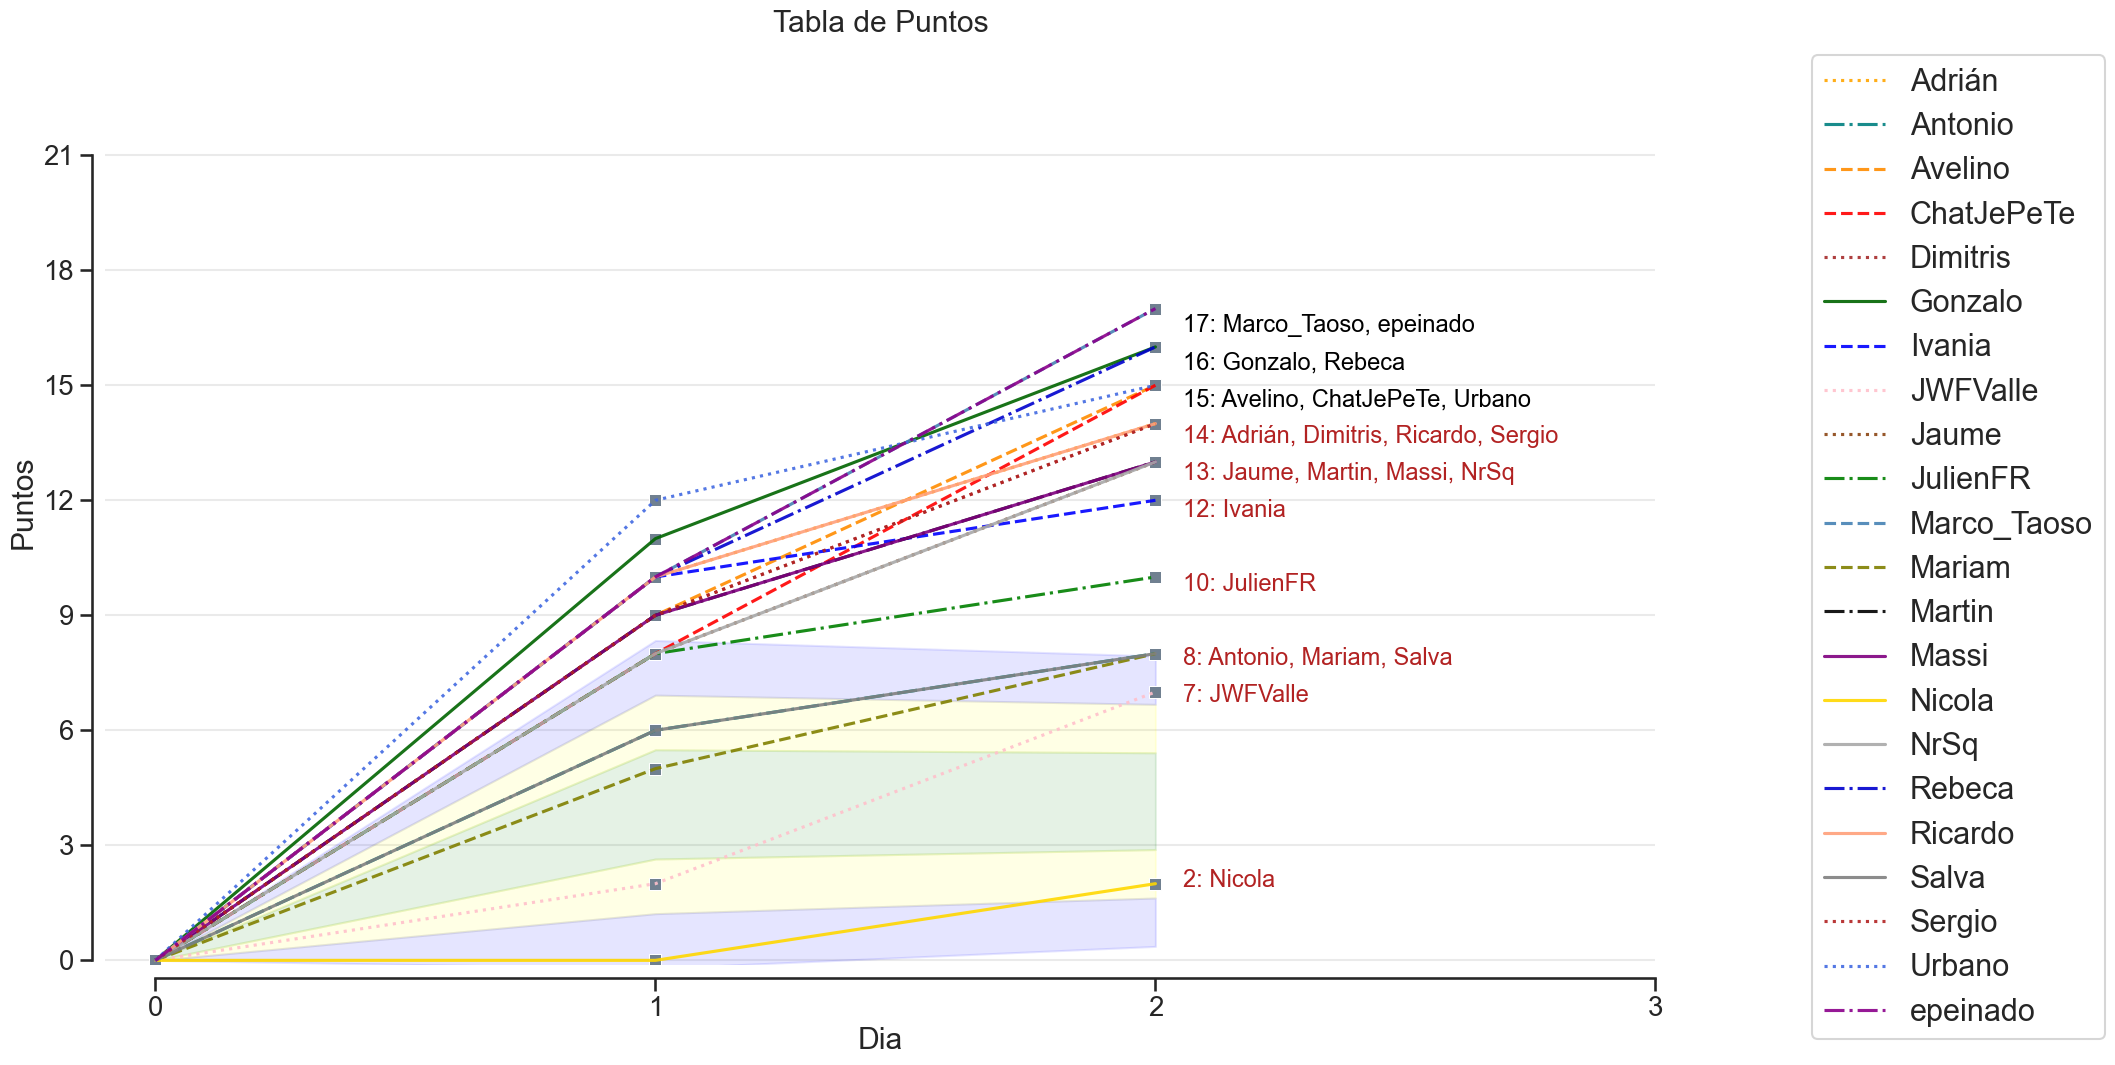

In [32]:
#expect.groupby('Month_Procedure')['BlastRate'].mean().plot()
from matplotlib import transforms as tf
from itertools import cycle, islice

sns.set(style="ticks", context="talk" , font_scale=1.2)
f, ax = plt.subplots(figsize=(20,12));

df_ec['Puntos'] = df_ec['Puntos'].astype(int)


#df_to_plot = df_ec.set_index('Day').groupby('Name')['Puntos']
df_to_plot = df_ec.pivot_table(values='Puntos', index='Day', columns='Name')
#display(df_to_plot)

# colors = ['FireBrick', 'FireBrick', 'FireBrick']
# i=0
# for name in list(df_to_plot['Name'].unique()):
#     df_to_plot[df_to_plot['Name']==name].plot(kind='line', marker='o', markersize = 10, alpha=0.7);
#     i+=1
    
players = [
    "Urbano", "Gonzalo", "Rebeca", "Ivania", "Adrián", "Ricardo",
    "epeinado", "Marco_Taoso", "Dimitris", "Massi", "Martin",
    "Avelino", "Sergio", "NrSq", "JulienFR", "ChatJePeTe",
    "Jaume", "Salva", "Antonio", "Mariam", "JWFValle", "Nicola"
]

colors = [
    "RoyalBlue", "DarkGreen", "MediumBlue", "Blue", "Orange", "LightSalmon",
    "DarkMagenta", "SteelBlue", "Brown", "Purple", "Black",
    "DarkOrange", "FireBrick", "DarkGray", "Green", "Red",
    "SaddleBrown", "Gray", "Teal", "Olive", "Pink", "Gold"
]

styles = [":", "-", "-.", "--"] * 6
markers = ["o", "s", "^", "v", "*", "D", "P", "X", "<", ">", "h"] * 2

color_dict = dict(zip(players, colors))
style_dict = dict(zip(players, styles[:len(players)]))
marker_dict = dict(zip(players, markers[:len(players)]))

alp=0.1

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - df_mean_std['std']), 
                 list(df_mean_std['mean'] + df_mean_std['std']), 
                 color='green', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - df_mean_std['std']), 
                 list(df_mean_std['mean'] - 2*df_mean_std['std']), 
                 color='yellow', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] + df_mean_std['std']), 
                 list(df_mean_std['mean'] + 2*df_mean_std['std']), 
                 color='yellow', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - 2*df_mean_std['std']), 
                 list(df_mean_std['mean'] - 3*df_mean_std['std']), 
                 color='blue', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] + 2*df_mean_std['std']), 
                 list(df_mean_std['mean'] + 3*df_mean_std['std']), 
                 color='blue', alpha=alp)


df_to_plot.plot(kind='line',  alpha=0.9, ax=ax,
                #marker = 'X',#[marker_dict.get(x, '#333333') for x in df_to_plot.columns],
                #markersize = 10, 
                style = [style_dict.get(x, '#333333') for x in df_to_plot.columns],
                color=[color_dict.get(x, '#333333') for x in df_to_plot.columns]);




sns.scatterplot(x ='Day' , y='Puntos', data=df_ec, ax=ax, marker = 's', color='SlateGrey')
                #marker = 'X',#[marker_dict.get(x, '#333333') for x in df_to_plot.columns],
                #markersize = 10, ;

df_ec_day = df_ec[df_ec['Day'] == df_ec['Day'].max()]
df_ec_day

# plt.fill_between(list(df_mean_std['Day']), 
#                  list(df_mean_std['mean'] - df_mean_std['std']), 
#                  list(df_mean_std['mean'] + df_mean_std['std']), 
#                  color='gray', alpha=0.2)

df_mean_std

loc_x_day = df_ec['Day'].max()+0.05

colors = ['FireBrick', 'FireBrick', 'FireBrick']#['ForestGreen', 'DarkOrange', 'FireBrick']
max_puntos = df_ec['Puntos'].max()
dict_puntos = {}
i = 0
for j in range(max_puntos,-1,-1):
    list_names = sorted(list(df_ec_day[df_ec_day['Puntos'] == j]['Name'].unique()))

    if len(list_names) > 0:
        dict_puntos[j] = list_names
        
        listToStr_names = ', '.join([str(elem) for elem in dict_puntos[j]])
        print(listToStr_names)
        
        ydiff = 0.07
        
        if i < 3:
            
            ax.annotate(str(j)+': '+listToStr_names,
                        (loc_x_day, j*(1-ydiff)),
                        xytext=(loc_x_day, j*(1-ydiff)),  size=17,
                        textcoords='offset points', color='Black')#color=colors[i])
        
        else:
            ax.annotate(str(j)+': '+listToStr_names,
                        (loc_x_day, j*(1-ydiff)),
                        xytext=(loc_x_day, j*(1-ydiff)),  size=17,
                        textcoords='offset points', color='FireBrick')
        
        
        i+=1

    
        
plt.ylim(-0.1,df_ec['Puntos'].max()+7)
plt.yticks(range(0, df_ec['Puntos'].max()+7, 3))

plt.xticks(range(0, df_ec['Day'].max()+2, 1))



plt.xlabel('Dia')
plt.ylabel('Puntos')
plt.title('Tabla de Puntos')

sns.despine(offset=10, trim=True)
ax.yaxis.grid(True, alpha=0.4)
ax.legend(bbox_to_anchor=(1.3, 1.0), loc=1, prop={'size': 22})
plt.savefig('figuras/resultados.jpg',bbox_inches='tight')

In [28]:
# df_to_plot = df_ec.pivot_table(values='Puntos_Day', index='Day', columns='Name')
# df_mean = df_to_plot.T.mean().reset_index(name='mean')#.groupby('Day')
# df_std = df_to_plot.T.std().reset_index(name='std')#.groupby('Day')
# df_mean_std = df_mean.merge(df_std, on='Day', how='outer')
# df_mean_std

Name,Adrián,Antonio,Avelino,ChatJePeTe,Dimitris,Gonzalo,Ivania,JWFValle,Jaume,JulienFR,...,Martin,Massi,Nicola,NrSq,Rebeca,Ricardo,Salva,Sergio,Urbano,epeinado
Day,,,,,,,,,,,,,,,,,,,,,
0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
1,5.00,3.00,4.5,4.0,4.50,5.50,5.0,1.00,4.00,4.00,...,4.50,4.50,0.00,4.00,5.00,5.00,3.00,4.50,6.0,5.00
2,4.67,2.67,5.0,5.0,4.67,5.33,4.0,2.33,4.33,3.33,...,4.33,4.33,0.67,4.33,5.33,4.67,2.67,4.67,5.0,5.67


Avelino, ChatJePeTe, Urbano
Adrián, Dimitris, Ricardo, Sergio
Antonio, Mariam, Salva
Ivania
Gonzalo, Rebeca
JWFValle
Jaume, Martin, Massi, NrSq
JulienFR
Marco_Taoso, epeinado
Nicola


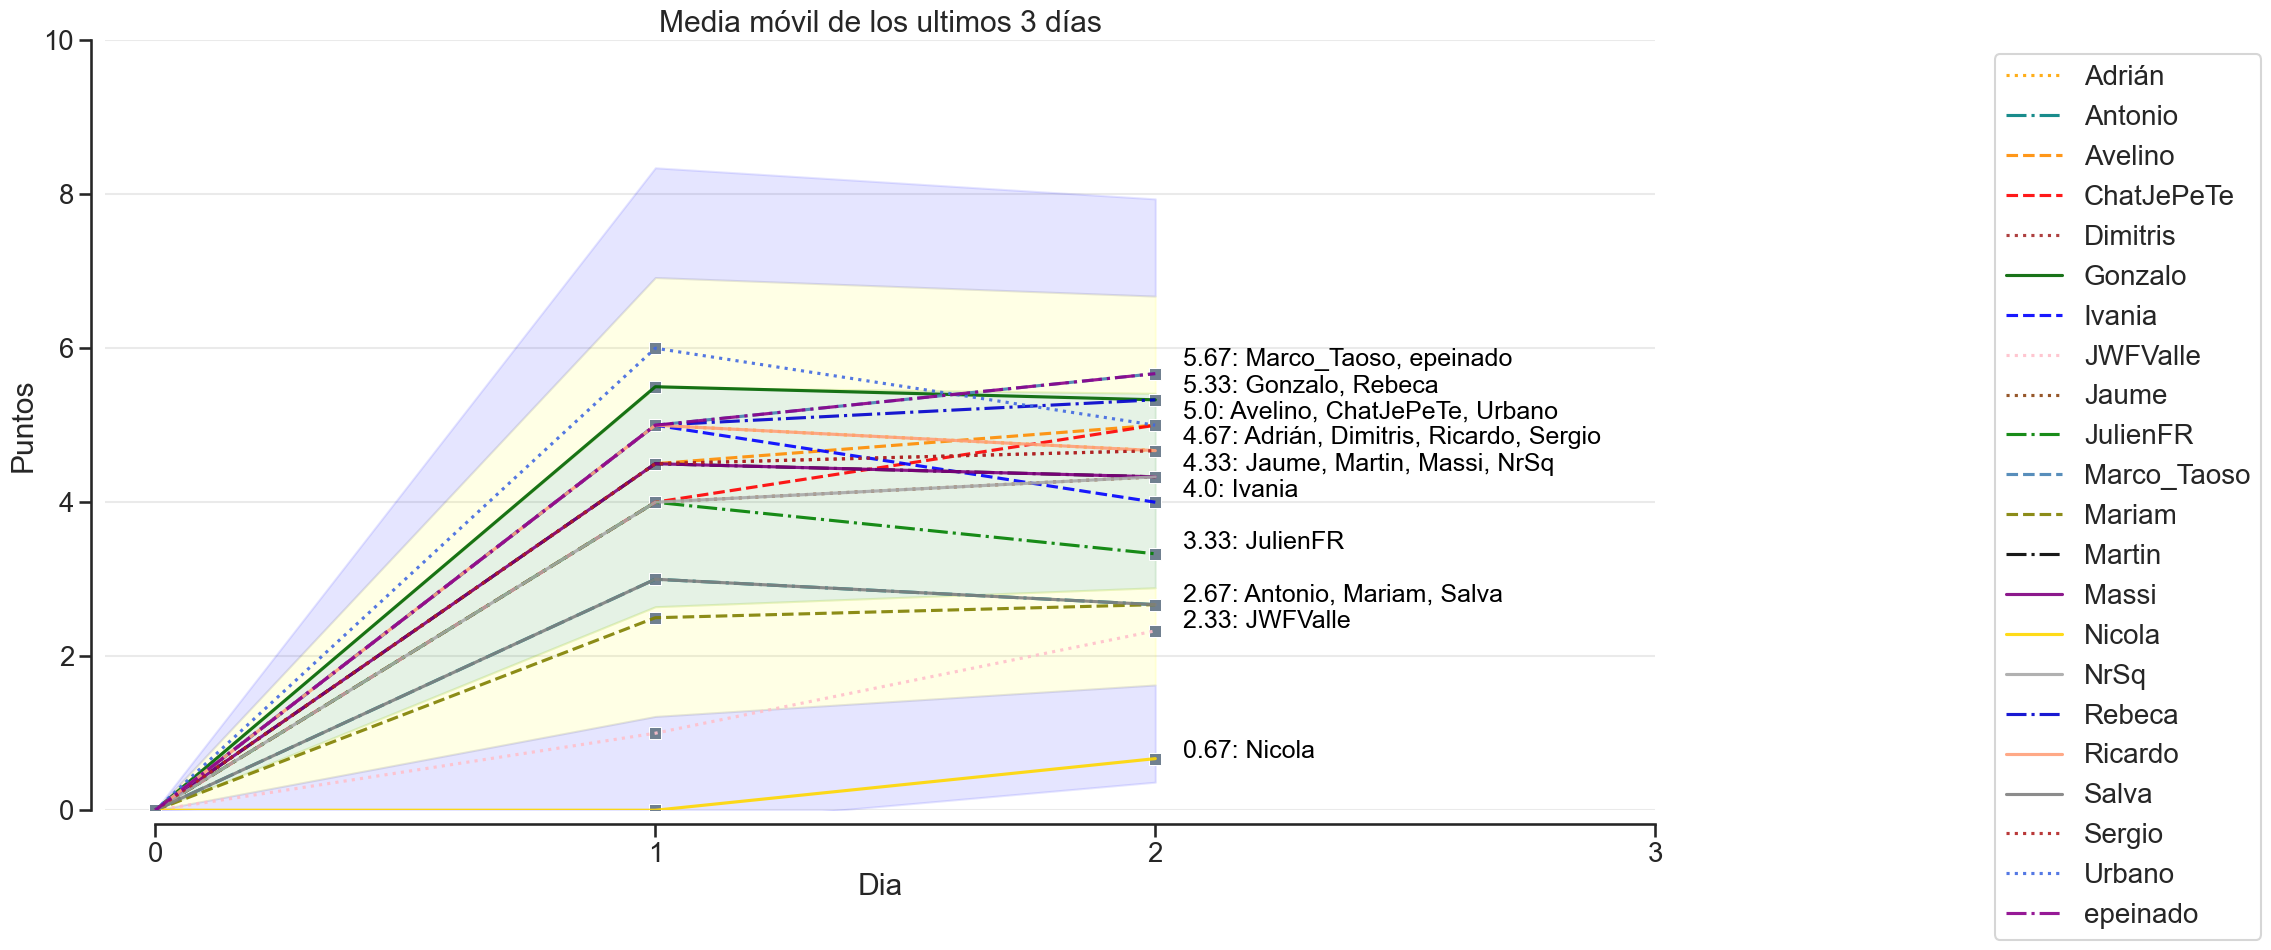

In [33]:
#expect.groupby('Month_Procedure')['BlastRate'].mean().plot()
from matplotlib import transforms as tf
from itertools import cycle, islice

sns.set(style="ticks", context="talk" , font_scale=1.2)
f, ax = plt.subplots(figsize=(20,10));

df_ec['Puntos_Day'] = df_ec['Puntos_Day'].astype(int)

df_ec['Media_movil'] = df_ec['Media_movil'].round(2)

df_to_plot = df_ec.pivot_table(values='Media_movil', index='Day', columns='Name')
#df_to_plot = df_to_plot.rolling(window=3).mean()

display(df_to_plot)

df_mean = df_to_plot.T.mean().reset_index(name='mean')#.groupby('Day')
df_std = df_to_plot.T.std().reset_index(name='std')#.groupby('Day')
df_mean_std = df_mean.merge(df_std, on='Day', how='outer')
df_mean_std

alp=0.1

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - df_mean_std['std']), 
                 list(df_mean_std['mean'] + df_mean_std['std']), 
                 color='green', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - df_mean_std['std']), 
                 list(df_mean_std['mean'] - 2*df_mean_std['std']), 
                 color='yellow', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] + df_mean_std['std']), 
                 list(df_mean_std['mean'] + 2*df_mean_std['std']), 
                 color='yellow', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] - 2*df_mean_std['std']), 
                 list(df_mean_std['mean'] - 3*df_mean_std['std']), 
                 color='blue', alpha=alp)

plt.fill_between(list(df_mean_std['Day']), 
                 list(df_mean_std['mean'] + 2*df_mean_std['std']), 
                 list(df_mean_std['mean'] + 3*df_mean_std['std']), 
                 color='blue', alpha=alp)



df_to_plot.plot(kind='line',  alpha=0.9, ax=ax,
                #marker = 'X',#[marker_dict.get(x, '#333333') for x in df_to_plot.columns],
                #markersize = 10, 
                style = [style_dict.get(x, '#333333') for x in df_to_plot.columns],
                color=[color_dict.get(x, '#333333') for x in df_to_plot.columns]);

sns.scatterplot(x ='Day' , y='Media_movil', data=df_ec, ax=ax, marker = 's', color='SlateGrey')
                #marker = 'X',#[marker_dict.get(x, '#333333') for x in df_to_plot.columns],
                #markersize = 10, ;

df_ec_day = df_ec[df_ec['Day'] == df_ec['Day'].max()]
df_ec_day

loc_x_day = df_ec['Day'].max()+0.05

colors = ['FireBrick', 'FireBrick', 'FireBrick']#['ForestGreen', 'DarkOrange', 'FireBrick']
max_puntos = df_ec['Media_movil'].max()
dict_puntos = {}
i = 0
for j in list(df_ec['Media_movil'].unique()):
    #j= round(j,3)
    list_names = sorted(list(df_ec_day[df_ec_day['Media_movil'] == j]['Name'].unique()))

    if len(list_names) > 0:
        dict_puntos[j] = list_names
        
        listToStr_names = ', '.join([str(elem) for elem in dict_puntos[j]])
        print(listToStr_names)
        
#        if i < 3:
            
        ax.annotate(str(j)+': '+listToStr_names,
                    (loc_x_day, j),
                    xytext=(loc_x_day, j),  size=18,
                    textcoords='offset points', color='Black')#color=colors[i])

#         else:
#             ax.annotate(str(j)+': '+listToStr_names,
#                         (loc_x_day, j),
#                         xytext=(loc_x_day, j),  size=20,
#                         textcoords='offset points', color='FireBrick')
        
        
        i+=1

plt.ylim(0,df_ec['Media_movil'].max()+4)

plt.xticks(range(0, df_ec['Day'].max()+2, 1))
plt.title('Media móvil de los ultimos 3 días')

plt.xlabel('Dia')
plt.ylabel('Puntos')


sns.despine(offset=10, trim=True)
ax.yaxis.grid(True, alpha=0.4)
ax.legend(bbox_to_anchor=(1.4, 1.0), loc=1, prop={'size': 20})
plt.savefig('figuras/resultados_rolling.jpg', bbox_inches='tight')